> **STALE — do not trust the outputs below.**
>
> This notebook is the exploratory fit carried over unchanged into the calib
> layout: only its file paths were repointed. Its results were produced on the
> 448-sample dataset from before the collector was fixed, and its last cell
> raises `NameError` without persisting the centering constants the exported
> coefficients depend on. It is kept as the record of what was tried.
>
> Rewriting it against `samples_all.csv` is the next task — see
> [`README.md`](README.md).

# Building the Linear Regression Model - Lena Sophie

Importing the data

In [34]:
# import the libraries
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Train/test splitting and validation
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    GroupKFold,
    cross_validate
)

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [35]:
# import the datasets
#
# Samples come from data/, which 01_source_extraction.ipynb writes and
# ensure_local() fills from Drive when this machine has never run the
# collection. Route lists and compositions are committed under sources/.
from data_sources import DATA_DIR, SEED_DIR, ensure_local, source_input

ontd_segments = pd.read_csv(source_input("routes_ontd.csv"))
compositions = pd.read_csv(source_input("compositions.csv"))
energy = pd.read_csv(ensure_local("samples_ontd.csv"))


In [36]:
# inspection

print(energy.shape)
print(energy.columns)

print(ontd_segments.shape)
print(ontd_segments.columns)

print(compositions.shape)
print(compositions.columns)

(448, 13)
Index(['route_name', 'start_stop_name', 'start_ds100', 'end_stop_name',
       'end_ds100', 'composition_id', 'n_coaches', 'weight_t', 'length_m',
       'v_max_kmh', 'energy_kwh', 'distance_km', 'travel_time_min'],
      dtype='str')
(96, 11)
Index(['route_name', 'all_routes_serving_segment', 'start_stop_id',
       'start_stop_name', 'start_ds100', 'end_stop_id', 'end_stop_name',
       'end_ds100', 'travel_duration_min', 'air_distance_km',
       'n_trip_occurrences'],
      dtype='str')
(8, 18)
Index(['composition_id', 'description', 'material_strategy', 'n_coaches',
       'total_places', 'places_by_class', 'loco_name', 'loco_baureihe',
       'trassenfinder_triebfahrzeug_hauptnummer', 'loco_weight_t',
       'loco_length_m', 'v_max_kmh', 'coaches_length_m_wagenzuglaenge',
       'coaches_net_weight_t', 'pax_load_80pct_t',
       'coaches_gross_weight_80pct_t_wagenzugmasse',
       'coaches_gross_weight_100pct_t', 'total_weight_incl_loco_80pct_t'],
      dtype='str')


Building the dataset

In [37]:
# merge the dataframes

data = (
    energy
    .merge(
        ontd_segments,
        on=[
            "route_name",
            "start_ds100",
            "end_ds100"
        ],
        how="left",
        suffixes=("", "_segment")
    )
    .merge(
        compositions,
        on="composition_id",
        how="left",
        suffixes=("", "_composition")
    )
)

data["avg_speed_kmh"] = (
    data["distance_km"]
    / (data["travel_time_min"] / 60)
)

In [38]:
# verify the merged df

print(data.shape)

print(data.isna().sum().sort_values(ascending=False).head(20))

data["segment_id"] = (
    data["route_name"].astype(str)
    + "__"
    + data["start_ds100"].astype(str)
    + "__"
    + data["end_ds100"].astype(str)
)

print(data["segment_id"].nunique())
print(data["composition_id"].nunique())

print(
    data.groupby("segment_id")
    ["composition_id"]
    .nunique()
    .value_counts()
)

(448, 39)
route_name                    0
start_stop_name               0
start_ds100                   0
end_stop_name                 0
end_ds100                     0
composition_id                0
n_coaches                     0
weight_t                      0
length_m                      0
v_max_kmh                     0
energy_kwh                    0
distance_km                   0
travel_time_min               0
all_routes_serving_segment    0
start_stop_id                 0
start_stop_name_segment       0
end_stop_id                   0
end_stop_name_segment         0
travel_duration_min           0
air_distance_km               0
dtype: int64
56
8
composition_id
8    56
Name: count, dtype: int64


In [39]:
# split into training and test datasets

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        data,
        groups=data["segment_id"]
    )
)

train = data.iloc[train_idx].copy()
test = data.iloc[test_idx].copy()

In [40]:
# leakage check

train_segments = set(train["segment_id"])
test_segments = set(test["segment_id"])

assert train_segments.isdisjoint(test_segments)

print("Training rows:", len(train))
print("Test rows:", len(test))

print("Training segments:", train["segment_id"].nunique())
print("Test segments:", test["segment_id"].nunique())

Training rows: 352
Test rows: 96
Training segments: 44
Test segments: 12


First regression model

In [41]:
# build an initial model

# centering the values
train["distance_c"] = (
    train["distance_km"]
    - train["distance_km"].mean()
)

train["weight_c"] = (
    train["weight_t"]
    - train["weight_t"].mean()
)

test["distance_c"] = (
    test["distance_km"]
    - train["distance_km"].mean()
)

test["weight_c"] = (
    test["weight_t"]
    - train["weight_t"].mean()
)

speed_mean = train["avg_speed_kmh"].mean()

train["speed_c"] = (
    train["avg_speed_kmh"] - speed_mean
)

test["speed_c"] = (
    test["avg_speed_kmh"] - speed_mean
)

model_initial = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + avg_speed_kmh
    """,
    data=train
).fit()

print(model_initial.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     2391.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):          8.57e-232
Time:                        10:38:59   Log-Likelihood:                -2419.3
No. Observations:                 352   AIC:                             4847.
Df Residuals:                     348   BIC:                             4862.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -467.9056    114.405     -4.090

In [42]:
# prediction using test data

test["predicted_energy_kwh"] = model_initial.predict(test)

# evaluate the model

mae = mean_absolute_error(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
)

rmse = mean_squared_error(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
) ** 0.5

r2 = r2_score(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 165.1666391893101
RMSE: 257.985125498909
R²: 0.9277255487337345


Building a baseline model for comparison

In [43]:
baseline_model = smf.ols(
    "energy_kwh ~ distance_km",
    data=train
).fit()

baseline_pred = baseline_model.predict(test)

baseline_mae = mean_absolute_error(
    test["energy_kwh"],
    baseline_pred
)

baseline_rmse = mean_squared_error(
    test["energy_kwh"],
    baseline_pred
) ** 0.5

baseline_r2 = r2_score(
    test["energy_kwh"],
    baseline_pred
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 208.0510235571576
Baseline RMSE: 328.7036206000753
Baseline R²: 0.882671249691689


In [44]:
# Statistical Errors

test["absolute_error"] = abs(
    test["energy_kwh"] - test["predicted_energy_kwh"]
)

test["relative_error_pct"] = (
    test["absolute_error"]
    / test["energy_kwh"]
    * 100
)

print(
    "Median relative error:",
    test["relative_error_pct"].median()
)

print(
    "Mean relative error:",
    test["relative_error_pct"].mean()
)

Median relative error: 13.548802926227083
Mean relative error: 22.79926249953426


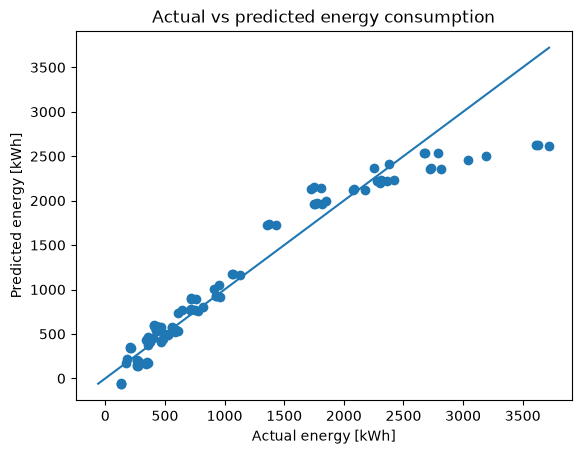

In [45]:
plt.figure()

plt.scatter(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
)

minimum = min(
    test["energy_kwh"].min(),
    test["predicted_energy_kwh"].min()
)

maximum = max(
    test["energy_kwh"].max(),
    test["predicted_energy_kwh"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual energy [kWh]")
plt.ylabel("Predicted energy [kWh]")
plt.title("Actual vs predicted energy consumption")

plt.show()

The mean and median relative errors should be checked to see where the residuals are clustered at

In [46]:
test["absolute_error"] = (
    test["energy_kwh"] - test["predicted_energy_kwh"]
).abs()

test["relative_error_pct"] = (
    test["absolute_error"]
    / test["energy_kwh"]
    * 100
)

worst = (
    test[
        [
            "route_name",
            "composition_id",
            "energy_kwh",
            "predicted_energy_kwh",
            "absolute_error",
            "relative_error_pct",
            "distance_km",
            "weight_t",
            "avg_speed_kmh"
        ]
    ]
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

print(worst)

              route_name composition_id  energy_kwh  predicted_energy_kwh  \
119  332/1372 = 333/1373     NEW-BAL-14        3721           2617.434792   
116  332/1372 = 333/1373     REF-BUD-12        3627           2627.918816   
117  332/1372 = 333/1373    REF-PREM-12        3610           2622.427184   
115  332/1372 = 333/1373   REF-COUCH-10        3191           2497.987727   
114  332/1372 = 333/1373      REF-BAL-9        3040           2458.394222   
103    320/324 = 321/325     NEW-BAL-14        2813           2353.384749   
353  NJ 40421 = NJ 40490    REF-COUCH-6        1728           2135.625603   
352  NJ 40421 = NJ 40490      REF-BUD-6        1749           2148.481013   
100    320/324 = 321/325     REF-BUD-12        2732           2363.448685   
289      NJ 402 = NJ 403    REF-COUCH-6        1357           1722.164376   

     absolute_error  relative_error_pct  distance_km  weight_t  avg_speed_kmh  
119     1103.565208           29.657759        442.8     627.6      95.5

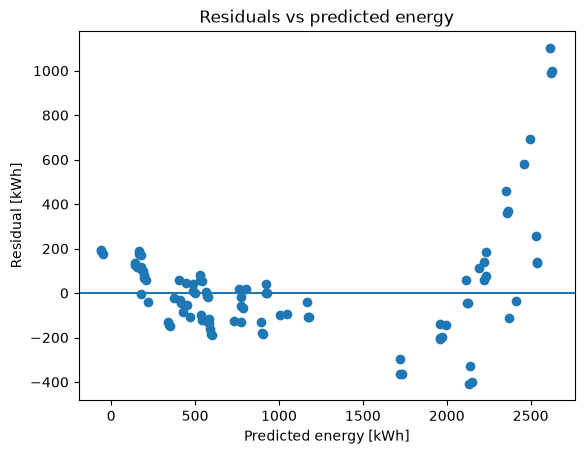

In [47]:
# residual plot

test["residual"] = (
    test["energy_kwh"]
    - test["predicted_energy_kwh"]
)

plt.figure()

plt.scatter(
    test["predicted_energy_kwh"],
    test["residual"]
)

plt.axhline(0)

plt.xlabel("Predicted energy [kWh]")
plt.ylabel("Residual [kWh]")
plt.title("Residuals vs predicted energy")

plt.show()

## Improving the models

In this step

### Variant 1

This is the original model

In [48]:
model_1 = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + avg_speed_kmh
    """,
    data=train
).fit()

### Variant 2

In this variant, instead of treating distance and weight as separate variables, the product of these two is taken as a single variable for the equation as an interaction term.

In [49]:
model_2 = smf.ols(
    """
    energy_kwh
    ~ distance_km * weight_t
    + avg_speed_kmh
    """,
    data=train
).fit()

### Variant 3

This variant accounts for non-linearity by converting the distance into a quadratic term

In [50]:
model_3 = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + I(distance_km ** 2)
    + weight_t
    + avg_speed_kmh
    """,
    data=train
).fit()

### Variant 4

This combines Variants 2 and 3 with both the interaction and quadratic terms

In [51]:
model_4 = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + I(distance_km ** 2)
    + weight_t
    + distance_km:weight_t
    + avg_speed_kmh
    """,
    data=train
).fit()

### Evaluating the refined models

In [52]:
models = {
    "initial": model_1,
    "interaction": model_2,
    "quadratic": model_3,
    "interaction + quadratic": model_4
}

results = []

for name, model in models.items():

    pred = model.predict(test)

    mae = mean_absolute_error(
        test["energy_kwh"],
        pred
    )

    rmse = mean_squared_error(
        test["energy_kwh"],
        pred
    ) ** 0.5

    r2 = r2_score(
        test["energy_kwh"],
        pred
    )

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

print(results_df)

                     model         MAE        RMSE        R2
0                  initial  165.166639  257.985125  0.927726
1              interaction  110.683208  192.930907  0.959580
2                quadratic  165.741570  254.253840  0.929801
3  interaction + quadratic  116.536370  187.437100  0.961849


Variants 2 and 4 are convincing, therefore residual test is conducted

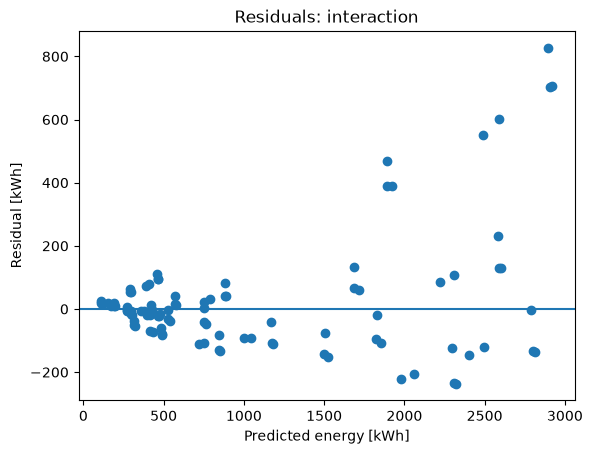

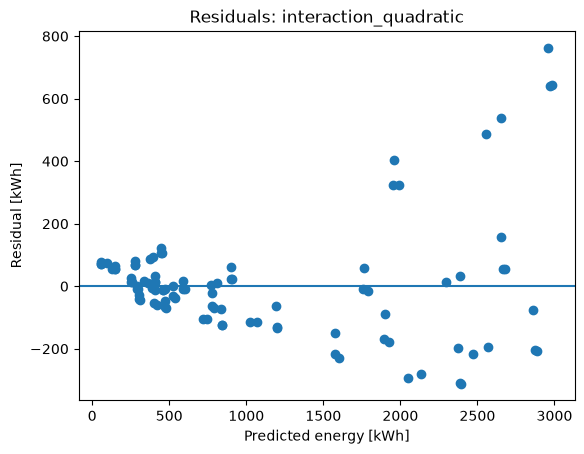

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     5199.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):          3.70e-308
Time:                        10:39:01   Log-Likelihood:                -2236.9
No. Observations:                 352   AIC:                             4484.
Df Residuals:                     347   BIC:                             4503.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              147.9621 

In [53]:
for name, model in {
    "interaction": model_2,
    "interaction_quadratic": model_4
}.items():

    pred = model.predict(test)
    residuals = test["energy_kwh"] - pred

    plt.figure()
    plt.scatter(pred, residuals)
    plt.axhline(0)

    plt.xlabel("Predicted energy [kWh]")
    plt.ylabel("Residual [kWh]")
    plt.title(f"Residuals: {name}")

    plt.show()


print(model_2.summary())
print(model_4.summary())

Using average speed as opposed to the Vmax as given from the dataset aligns the regression more closely with the intended backend inputs. The estimated coefficient for average speed is negative, suggesting that, conditional on distance and train weight, routes with higher average speeds tend to consume less energy. This likely reflects operational efficiency effects—such as fewer stops or smoother running conditions—rather than a purely causal speed effect. The distance–weight interaction remained highly stable, reinforcing the conclusion that the energy impact of train mass increases with route length.

In [54]:
print(data[["distance_km", "avg_speed_kmh", "travel_time_min", "weight_t", "energy_kwh"]].corr())

                 distance_km  avg_speed_kmh  travel_time_min  weight_t  \
distance_km         1.000000       0.304007         0.998703  0.001335   
avg_speed_kmh       0.304007       1.000000         0.269658 -0.092275   
travel_time_min     0.998703       0.269658         1.000000  0.008292   
weight_t            0.001335      -0.092275         0.008292  1.000000   
energy_kwh          0.959505       0.260680         0.962051  0.170627   

                 energy_kwh  
distance_km        0.959505  
avg_speed_kmh      0.260680  
travel_time_min    0.962051  
weight_t           0.170627  
energy_kwh         1.000000  


The dataset is overwhelmingly structured by route length, while average speed and weight provide secondary information; travel time is almost perfectly collinear with distance and should therefore not be included alongside it.

In [55]:
# VIF check

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = train[["distance_km", "weight_t", "avg_speed_kmh"]].copy()
X["distance_weight"] = train["distance_km"] * train["weight_t"]

X = sm.add_constant(X)

vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif_df)

          variable        VIF
0            const  94.141102
1      distance_km  13.453516
2         weight_t   1.771409
3    avg_speed_kmh   1.143298
4  distance_weight  14.155065


In [56]:
# VIF check on a centered model

train["distance_weight_c"] = (
    train["distance_c"] * train["weight_c"]
)

X = train[
    [
        "distance_c",
        "weight_c",
        "avg_speed_kmh",
        "distance_weight_c"
    ]
].copy()

X = sm.add_constant(X)

vif_df2 = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif_df2)

            variable        VIF
0              const  70.006262
1         distance_c   1.133485
2           weight_c   1.009185
3      avg_speed_kmh   1.143298
4  distance_weight_c   1.000699


In [57]:
model_centered = smf.ols(
    """
    energy_kwh
    ~ distance_c
    + weight_c
    + avg_speed_kmh
    + distance_c:weight_c
    """,
    data=train
).fit(cov_type="HC3")

model_centered_quad = smf.ols(
    """
    energy_kwh
    ~ distance_c
    + I(distance_c ** 2)
    + weight_c
    + avg_speed_kmh
    + distance_c:weight_c
    """,
    data=train
).fit(cov_type="HC3")

print(model_centered.summary())
print(model_centered_quad.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     2862.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):          3.50e-264
Time:                        10:39:01   Log-Likelihood:                -2236.9
No. Observations:                 352   AIC:                             4484.
Df Residuals:                     347   BIC:                             4503.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1092.7849    

In [58]:
for name, model in {
    "centered_interaction": model_centered,
    "centered_interaction_quad": model_centered_quad
}.items():

    pred = model.predict(test)

    print(name)
    print("MAE:", mean_absolute_error(test["energy_kwh"], pred))
    print("RMSE:", mean_squared_error(test["energy_kwh"], pred) ** 0.5)
    print("R²:", r2_score(test["energy_kwh"], pred))
    print()

centered_interaction
MAE: 110.68320788150272
RMSE: 192.9309071349905
R²: 0.9595797419309622

centered_interaction_quad
MAE: 116.5363697943679
RMSE: 187.43709964914518
R²: 0.96184894251651



In [59]:
print(model_centered.summary())
print(model_centered_quad.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     2862.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):          3.50e-264
Time:                        10:39:01   Log-Likelihood:                -2236.9
No. Observations:                 352   AIC:                             4484.
Df Residuals:                     347   BIC:                             4503.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1092.7849    

## Clustering and cross-validation

In [60]:
model_quad_clustered = smf.ols(
    """
    energy_kwh
    ~ distance_c
    + I(distance_c ** 2)
    + weight_c
    + speed_c
    + distance_c:weight_c
    """,
    data=train
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train["segment_id"]
    }
)

model_interaction_clustered = smf.ols(
    """
    energy_kwh
    ~ distance_c
    + weight_c
    + speed_c
    + distance_c:weight_c
    """,
    data=train
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train["segment_id"]
    }
)

print(model_quad_clustered.summary())
print(model_interaction_clustered.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     1442.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           1.06e-46
Time:                        10:39:01   Log-Likelihood:                -2216.2
No. Observations:                 352   AIC:                             4444.
Df Residuals:                     346   BIC:                             4468.
Df Model:                           5                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             996.2932    

In [61]:
formula_interaction = """
energy_kwh
~ distance_c
+ weight_c
+ speed_c
+ distance_c:weight_c
"""

formula_quadratic = """
energy_kwh
~ distance_c
+ I(distance_c ** 2)
+ weight_c
+ speed_c
+ distance_c:weight_c
"""

gkf = GroupKFold(n_splits=5)

groups = train["segment_id"]

results = []

formulas = {
    "interaction": formula_interaction,
    "interaction_quadratic": formula_quadratic
}

for model_name, formula in formulas.items():

    fold = 1

    for train_idx, val_idx in gkf.split(
        train,
        groups=groups
    ):

        cv_train = train.iloc[train_idx].copy()
        cv_val = train.iloc[val_idx].copy()

        model = smf.ols(
            formula,
            data=cv_train
        ).fit()

        pred = model.predict(cv_val)

        mae = mean_absolute_error(
            cv_val["energy_kwh"],
            pred
        )

        rmse = mean_squared_error(
            cv_val["energy_kwh"],
            pred
        ) ** 0.5

        r2 = r2_score(
            cv_val["energy_kwh"],
            pred
        )

        results.append({
            "model": model_name,
            "fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        fold += 1

cv_results = pd.DataFrame(results)

print(cv_results)

summary = (
    cv_results
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_sd=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_sd=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_sd=("R2", "std")
    )
)

print(summary)

                   model  fold         MAE        RMSE        R2
0            interaction     1   63.352817   84.481377  0.988783
1            interaction     2  131.580026  185.011800  0.971630
2            interaction     3  144.403344  210.639800  0.936736
3            interaction     4  134.103682  197.387075  0.979692
4            interaction     5   71.614566  102.244944  0.990096
5  interaction_quadratic     1   65.269323   92.068502  0.986678
6  interaction_quadratic     2  120.454925  168.633787  0.976431
7  interaction_quadratic     3  143.016667  200.155089  0.942877
8  interaction_quadratic     4  111.997438  151.094071  0.988100
9  interaction_quadratic     5   61.191309   86.879133  0.992849
                         MAE_mean     MAE_sd   RMSE_mean    RMSE_sd   R2_mean  \
model                                                                           
interaction            109.010887  38.323572  155.952999  58.190615  0.973387   
interaction_quadratic  100.385932  35.7923

Grouped five-fold cross-validation was used to compare an interaction model with a model additionally containing a quadratic distance term. Grouping by route segment ensured that all train compositions for a given segment remained within the same fold. The interaction-plus-quadratic specification achieved lower mean MAE (100.4 vs. 109.0 kWh), lower mean RMSE (139.8 vs. 156.0 kWh), and higher mean R^2 (0.9774 vs. 0.9734). It was therefore selected for validation towards the final model.

## The candidate model

In [62]:
candidate_model = smf.ols(
    """
    energy_kwh
    ~ distance_c
    + I(distance_c ** 2)
    + weight_c
    + speed_c
    + distance_c:weight_c
    """,
    data=train
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train["segment_id"]
    }
)

print(candidate_model.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     1442.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           1.06e-46
Time:                        10:39:01   Log-Likelihood:                -2216.2
No. Observations:                 352   AIC:                             4444.
Df Residuals:                     346   BIC:                             4468.
Df Model:                           5                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             996.2932    

In [63]:
test["predicted_energy_kwh"] = candidate_model.predict(test)

test["residual"] = (
    test["energy_kwh"]
    - test["predicted_energy_kwh"]
)

In [64]:
candidate_mae = mean_absolute_error(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
)

candidate_rmse = mean_squared_error(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
) ** 0.5

candidate_r2 = r2_score(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
)

print(f"candidate test MAE:  {candidate_mae:.1f} kWh")
print(f"candidate test RMSE: {candidate_rmse:.1f} kWh")
print(f"candidate test R²:   {candidate_r2:.4f}")

candidate test MAE:  116.5 kWh
candidate test RMSE: 187.4 kWh
candidate test R²:   0.9618


In [65]:
test["absolute_error"] = test["residual"].abs()

test["relative_error_pct"] = (
    test["absolute_error"]
    / test["energy_kwh"]
    * 100
)

print(
    "Median relative error:",
    test["relative_error_pct"].median()
)

print(
    "Mean relative error:",
    test["relative_error_pct"].mean()
)

Median relative error: 9.964890569545167
Mean relative error: 12.246802838213165


On the held-out route-level test set, the selected quadratic interaction model achieved an MAE of 116.5 kWh, RMSE of 187.4 kWh, and R2 of 0.9618. The median relative error was approximately 10.0% and the mean relative error approximately 12.2%. This indicates strong generalisation to unseen German route segments, although additional validation is still required for different terrain classes and countries.

In [67]:
coef_table = pd.DataFrame({
    "coefficient": candidate_model.params,
    "std_error": candidate_model.bse,
    "p_value": candidate_model.pvalues
})

coef_table.to_csv(SEED_DIR / "energy_coefficients.csv")

test[
    [
        "segment_id",
        "composition_id",
        "energy_kwh",
        "predicted_energy_kwh",
        "absolute_error",
        "relative_error_pct"
    ]
].to_csv(DATA_DIR / "holdout_predictions.csv", index=False)

centering = {
    "distance_mean": distance_mean,
    "weight_mean": weight_mean,
    "speed_mean": speed_mean
}

print(centering)

NameError: name 'distance_mean' is not defined